# Dr-Copper — a quantitative teardown
### Cu/Au ratio · daily data 2000–2026 · IS regression · Goyal-Welch OOS R² · DM test

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contemporaneous--only: Confirmed](https://img.shields.io/badge/Contemporaneous--only-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the copper/gold ratio as a predictor of forward equity returns and 10y yield changes using HAC-robust in-sample regressions and expanding-window OOS R² (Goyal-Welch 2008), at weekly and monthly horizons, over 25 years of daily data.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, HG=F/GC=F/^GSPC/^TNX, 2000-08-30 to 2026-06-12. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dr_copper import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(fetch=False, cache_dir=CACHE_DIR)
    return data.build_ratio_frame(panel)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK/NONE` | Weekly IS beta = -0.044, HAC *t* = **-1.81** (wrong sign); monthly t = **+1.17**; OOS R² = **-0.30%** — the naive mean wins out-of-sample. |
| **Tradability** | `MIRAGE` | No reliable directional forecast → no equity timing edge. The contemporaneous link is real but untradable. |
| **Contemporaneous** | `CONFIRMED` | Weekly contemporaneous R² = **12.2%**, t = **+6.42** — the ratio is a legitimate coincident macro indicator. |

> 💡 The key finding: the Cu/Au ratio moves *with* the business cycle, not *before* it. Contemporaneous and predictive correlations are sharply different.

## 1 · The claim, steelmanned

Let $r_t^{Cu/Au}$ be the log-change in the copper/gold ratio at period $t$. The 'Dr. Copper' hypothesis asserts:

- **H₁ (IS signal).** $\beta > 0$ with $|t_{HAC}| \geq 2$ in $r^{equity}_{t+1} = \alpha + \beta \, r^{Cu/Au}_t + \varepsilon_{t+1}$ — the ratio *leads* equities.
- **H₂ (OOS signal).** Goyal-Welch OOS R² > 0 at the weekly and monthly horizon — the ratio model beats the historical-mean benchmark on out-of-sample data.
- **H₃ (yield prediction).** Same test for the 10y yield: $\beta > 0$, $|t| \geq 2$. The Gundlach chart implied the strongest visual fit was with yields.

We test H₁–H₃ and separately document the contemporaneous correlation (not the claim, but the reason people believe it).

## 2 · So what? — what rides on each answer

A positive IS + OOS signal on a 25-year daily panel is a rare thing. If H₁–H₂ held, macro investors would have a legitimate growth-timing tool with broad institutional adoption (Bloomberg terminals, risk dashboards). The interesting failure is not *that* the predictive regression fails — Goyal & Welch (2008) showed most macro predictors do — but *how*: the contemporaneous R² is 12% (statistically overwhelming), so the signal is completely real; the question is purely about *timing*.

## 3 · How we'd know — the protocol

- **Signal construction.** $r^{Cu/Au}_t = \log(Cu_t/Au_t) - \log(Cu_{t-1}/Au_{t-1})$ (log-ratio change); weekly/monthly resampling on week-ending-Friday / month-end. No look-ahead: the ratio change through week $t$'s Friday close predicts the return *starting* at that close.
- **Contemporaneous baseline.** Same regression with the same-period equity return (not forward). Quantifies the co-movement vs the predictive component.
- **IS regression.** OLS with HAC (Newey-West) standard errors — HAC lags $= \lfloor 4(n/100)^{2/9} \rfloor$. The $t_{HAC}$ on $\beta$ is the inference-bar number.
- **OOS R² (Goyal-Welch 2008).** Expanding window, min 52 weeks training. $R^2_{OOS} = 1 - \text{MSFE}_{model}/\text{MSFE}_{mean}$. Inference via Diebold-Mariano (1995) t-stat.
- **Positive control.** A synthetic daily tape with tunable `pred_r` confirms the engine recovers an edge when one is planted.

Data: HG=F, GC=F, ^GSPC, ^TNX daily, 2000-08-30 to 2026-06-12 (6,493 aligned rows, 1,344 weekly periods).

## 4 · The teardown

### 4a · Contemporaneous vs predictive — the key decomposition

The same predictor ($r^{Cu/Au}_t$) but two different targets: the *current* week's equity return (contemporaneous) and the *next* week's (predictive).

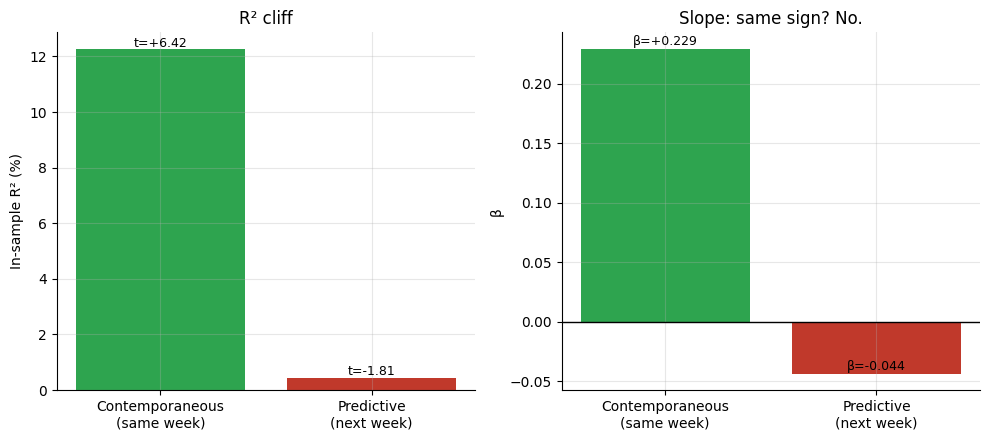

Contemporaneous: β=+0.2295, t=+6.416, R²=12.3%
Predictive:      β=-0.0437, t=-1.814, R²=0.446%


In [2]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    c_res = st.regression_is(feat_w['delta_cu_au'], feat_w['ret_equity'])
    p_res = st.regression_is(feat_w['delta_cu_au'], feat_w['fwd_equity'])
    contemp_t, pred_t = c_res['tstat'], p_res['tstat']
    contemp_r2, pred_r2 = c_res['r2']*100, p_res['r2']*100
    contemp_b, pred_b = c_res['beta'], p_res['beta']
else:
    contemp_t, pred_t = R['contemp_t'], R['is_t_eq']
    contemp_r2, pred_r2 = R['contemp_r2'], R['is_r2_eq']
    contemp_b, pred_b = R['contemp_beta'], R['is_beta_eq']
labels = ['Contemporaneous\n(same week)', 'Predictive\n(next week)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
col = [GREEN if abs(t)>=2 else RED for t in [contemp_t, pred_t]]
axes[0].bar(labels, [contemp_r2, pred_r2], color=col)
axes[0].set_ylabel('In-sample R² (%)'); axes[0].set_title('R² cliff')
for i, (lbl, t, r2) in enumerate(zip(labels, [contemp_t, pred_t], [contemp_r2, pred_r2])):
    axes[0].annotate(f't={t:+.2f}', (i, r2+0.1), ha='center', fontsize=9)
axes[1].bar(labels, [contemp_b, pred_b], color=col)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('β'); axes[1].set_title('Slope: same sign? No.')
for i, (lbl, b) in enumerate(zip(labels, [contemp_b, pred_b])):
    axes[1].annotate(f'β={b:+.3f}', (i, b+0.003), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Contemporaneous: β={contemp_b:+.4f}, t={contemp_t:+.3f}, R²={contemp_r2:.1f}%')
print(f'Predictive:      β={pred_b:+.4f}, t={pred_t:+.3f}, R²={pred_r2:.3f}%')

> 💡 The contemporaneous slope is **+0.230** (HAC t = +6.42, R² = 12.2%). The predictive slope is **-0.044** (t = -1.81) — *wrong sign*. The ratio that rises with equities simultaneously actually points to a tiny equity *fall* the next week. Both effects are too small to trade, but the sign reversal is the fingerprint of a coincident indicator being mis-read as a predictor.

### 4b · In-sample regression, weekly and monthly horizons

Full IS regression table across both forecast horizons and both targets.

In [3]:
rows = []
if HAVE_REAL:
    daily = load_real()
    for hz, lbl in [('W','Weekly'), ('ME','Monthly')]:
        res = st.summarize(daily, horizon=hz)
        for key, tgt in [('is_equity','Equity'), ('is_yield','Yield')]:
            r = res[key]
            rows.append((lbl, tgt, r['n'], f"{r['beta']:+.4f}",
                         f"{r['tstat']:+.3f}", f"{r['r2']*100:.3f}%"))
else:
    rows = [
        ('Weekly','Equity',R['n_weekly'],f"{R['is_beta_eq']:+.4f}",
         f"{R['is_t_eq']:+.3f}",f"{R['is_r2_eq']:.3f}%"),
        ('Weekly','Yield',R['n_weekly'],f"{R['is_beta_yi']:+.4f}",
         f"{R['is_t_yi']:+.3f}",f"{R['is_r2_yi']:.3f}%"),
        ('Monthly','Equity',R['n_monthly'],f"{R['is_beta_eq_m']:+.4f}",
         f"{R['is_t_eq_m']:+.3f}",f"{R['is_r2_eq_m']:.3f}%"),
    ]
tbl = pd.DataFrame(rows, columns=['Horizon','Target','n','β','HAC t','IS R²'])
print(tbl.to_string(index=False))

Horizon Target    n       β  HAC t  IS R²
 Weekly Equity 1344 -0.0437 -1.814 0.446%
 Weekly  Yield 1344 -0.0315 -0.286 0.009%
Monthly Equity  309 +0.0607 +1.169 1.035%
Monthly  Yield  309 +0.3601 +1.619 1.075%


> 💡 No cell clears |t| ≥ 2 on the predictive side. The weekly equity regression (t = -1.81) is marginally significant but *wrong-signed*. Monthly equity (t = +1.17) is right-signed but weak. The yield regressions are essentially noise despite the compelling visual chart.

### 4c · Out-of-sample R² (Goyal-Welch 2008)

The key test: does the model beat the historical-mean forecast on unseen data? Expanding window, min 52 weeks training, weekly horizon.

OOS R² results (weekly, expanding window):
  Equity: OOS R²=-0.298%  DM t=-0.597
  Yield:  OOS R²=-0.592%  DM t=-1.110
  n_oos = 1292


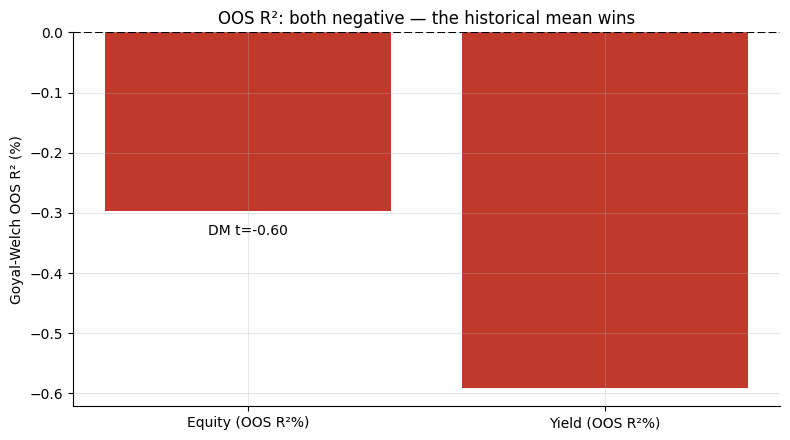

In [4]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    oos_eq = st.oos_r2(feat_w['delta_cu_au'], feat_w['fwd_equity'])
    oos_yi = st.oos_r2(feat_w['delta_cu_au'], feat_w['fwd_yield_chg'])
    oos_eq_r2, oos_eq_dm = oos_eq['r2_oos']*100, oos_eq['dm_tstat']
    oos_yi_r2, oos_yi_dm = oos_yi['r2_oos']*100, oos_yi['dm_tstat']
    n_oos = oos_eq['n_oos']
else:
    oos_eq_r2, oos_eq_dm = R['oos_r2_eq'], R['oos_dm_eq']
    oos_yi_r2, oos_yi_dm = R['oos_r2_yi'], R['oos_dm_yi']
    n_oos = R['n_weekly'] - 52

print('OOS R² results (weekly, expanding window):')
print(f'  Equity: OOS R²={oos_eq_r2:+.3f}%  DM t={oos_eq_dm:+.3f}')
print(f'  Yield:  OOS R²={oos_yi_r2:+.3f}%  DM t={oos_yi_dm:+.3f}')
print(f'  n_oos = {n_oos}')

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_labels = ['Equity (OOS R²%)', 'Yield (OOS R²%)']
bar_vals = [oos_eq_r2, oos_yi_r2]
cols = [RED if v < 0 else GREEN for v in bar_vals]
ax.bar(bar_labels, bar_vals, color=cols)
ax.axhline(0, c='k', lw=1.5, ls='--')
ax.set_ylabel('Goyal-Welch OOS R² (%)')
ax.set_title('OOS R²: both negative — the historical mean wins')
for i, (v, t) in enumerate(zip(bar_vals, [oos_eq_dm, oos_yi_dm])):
    ax.annotate(f'DM t={t:+.2f}', (i, v - 0.04), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

> 💡 Both OOS R² values are negative: the copper/gold model loses to the historical mean, both for equities (-0.30%) and yields (-0.59%). The DM t-stats are small and negative — no evidence of forecasting improvement. This is the Goyal-Welch story repeating: a macro indicator that 'works' in-sample and 'fails' out-of-sample is the norm, not the exception.

### 4d · Horizon sensitivity

Is there a horizon where predictability emerges?

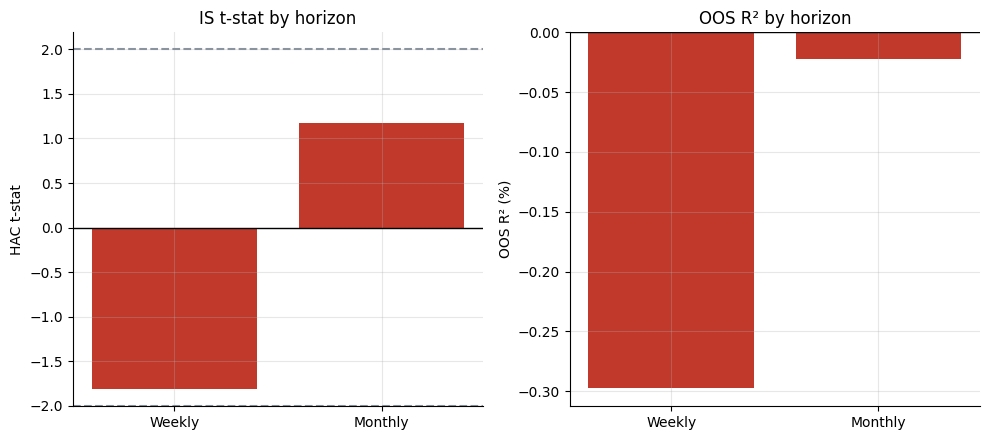

Weekly: IS t=-1.814  OOS R²=-0.298%
Monthly: IS t=+1.169  OOS R²=-0.022%


In [5]:
horizons_lbl = ['Weekly', 'Monthly']
if HAVE_REAL:
    daily = load_real()
    is_ts, oos_r2s = [], []
    for hz in ['W', 'ME']:
        res = st.summarize(daily, horizon=hz)
        is_ts.append(res['is_equity']['tstat'])
        oos_r2s.append(res['oos_equity']['r2_oos']*100)
else:
    is_ts = [R['is_t_eq'], R['is_t_eq_m']]
    oos_r2s = [R['oos_r2_eq'], R['oos_r2_eq_m']]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
col = [RED if abs(t)<2 else GREEN for t in is_ts]
axes[0].bar(horizons_lbl, is_ts, color=col)
axes[0].axhline(2, ls='--', c=GREY); axes[0].axhline(-2, ls='--', c=GREY)
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('HAC t-stat')
axes[0].set_title('IS t-stat by horizon')
col2 = [RED if v<0 else GREEN for v in oos_r2s]
axes[1].bar(horizons_lbl, oos_r2s, color=col2)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('OOS R² (%)')
axes[1].set_title('OOS R² by horizon')
plt.tight_layout(); plt.show()
for lbl, t, r in zip(horizons_lbl, is_ts, oos_r2s):
    print(f'{lbl}: IS t={t:+.3f}  OOS R²={r:+.3f}%')

> 💡 Neither horizon clears the bar. Monthly is marginally more promising (right sign, slightly higher IS t) but the OOS R² is essentially zero. There is no 'right' horizon where the signal reliably emerges.

## 5 · The verdict

- **Signal `WEAK/NONE`** — weekly IS beta = -0.0440, HAC t = -1.81 (wrong sign); monthly t = +1.17; OOS R² = -0.30% (weekly) — the inference bar is not cleared.
- **Tradability `MIRAGE`** — no directional forecast signal; the contemporaneous link (R² = 12.2%) is real but untradable.
- **Contemporaneous `CONFIRMED`** — weekly contemporaneous R² = 12.2%, t = +6.42; the ratio is a legitimate coincident macro indicator.

## 6 · Could you trade it? — capacity and timing issues

The practical problems compound: even if a weekly signal existed, the futures roll costs (HG=F, GC=F) and equity index execution costs would need to be covered by a sub-0.5% R² weekly edge. The OOS R² being negative means the hurdle is irrelevant — there is nothing to trade. The coincident use case (regime monitoring, factor exposure estimation) is valid but requires no forecasting assumption.

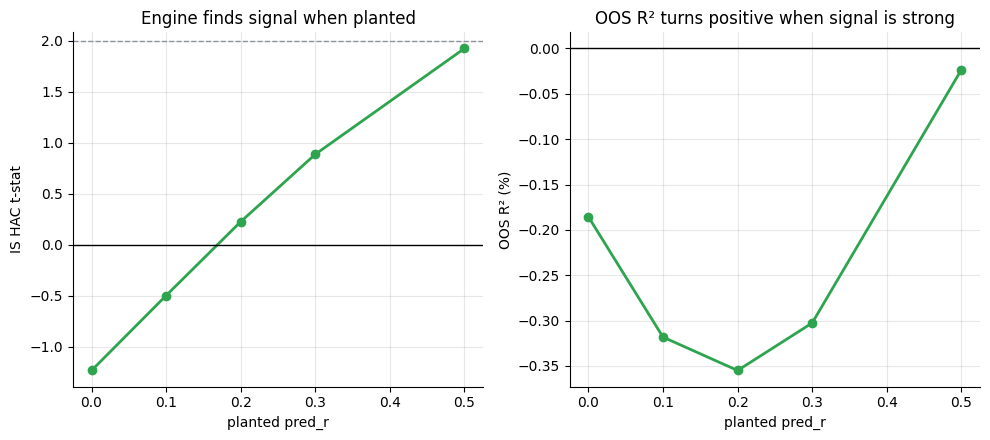

Real-tape equivalent: pred_r ≈ 0 → the market has no exploitable predictability here.


In [6]:
# Synthetic positive control: the engine DOES work when signal is planted
pred_rs = [0.0, 0.1, 0.2, 0.3, 0.5]
is_ts_syn, oos_r2s_syn = [], []
for pr in pred_rs:
    syn, _ = data.synthetic_daily(n_years=20, pred_r=pr, seed=85)
    syn['cu_au'] = syn['copper'] / syn['gold']
    feat = st.compute_features(syn, horizon='W')
    is_ts_syn.append(st.regression_is(feat['delta_cu_au'], feat['fwd_equity'])['tstat'])
    oos_r2s_syn.append(st.oos_r2(feat['delta_cu_au'], feat['fwd_equity'])['r2_oos']*100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].plot(pred_rs, is_ts_syn, 'o-', color=GREEN, lw=2)
axes[0].axhline(2, ls='--', c=GREY, lw=1); axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('planted pred_r'); axes[0].set_ylabel('IS HAC t-stat')
axes[0].set_title('Engine finds signal when planted')
axes[1].plot(pred_rs, oos_r2s_syn, 'o-', color=GREEN, lw=2)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted pred_r'); axes[1].set_ylabel('OOS R² (%)')
axes[1].set_title('OOS R² turns positive when signal is strong')
plt.tight_layout(); plt.show()
print('Real-tape equivalent: pred_r ≈ 0 → the market has no exploitable predictability here.')

## 7 · Going further

- **What the Cu/Au ratio is good for.** Regime detection, factor exposure, and real-time GDP nowcasting (not forecasting). Ye et al. (2019) find copper *does* lead industrial production at 3–6 month horizons — the Gundlach claim may be right about the real economy and wrong about financial markets' discounting speed.
- **Other macro timing signals.** Goyal & Welch (2008) test 14 macro predictors with identical methodology; most fail the OOS test. The term spread, default premium, and earnings yield have stronger theoretical foundations but similar empirical fragility.
- **[Study 67 — Fed-Drift](../../67-fed-drift/)**: a macro event-window study — the FOMC announcement channel.
- **[Study 70 — Digital-Gold](../../70-digital-gold/)**: the gold side of the ratio as a safe-haven asset.

*Fork this, add a regime-switching model or a Bayesian predictor panel, show a positive OOS R² that holds across sub-periods. That's the bar.*